# `pygtf2` (multi-species version) demo

This walkthrough starts with a two-species simulation, follows substantial core contraction, and compares a second particle mass ratio.  It then shows how to inspect saved data, compare physical times, configure other physics, and check numerical resolution.  The final section covers movies.

Running all cells creates new model directories under `demo_output`.  The numerical examples run by default; MP4 generation is opt-in.  The profile catalogue shows configuration options without solving every profile.

## Import

Use a Python 3.12+ kernel with this checkout installed (`python -m pip install -e .` from the repository root, using the kernel's Python).  The examples below write new simulation outputs beneath `demo_output` in the working directory.

In [1]:
import pygtf2 as gtf
from pathlib import Path
from copy import deepcopy
import numpy as np

## Instantiate config object

In [2]:
base_dir = Path.cwd() / 'demo_output'
base_dir.mkdir(exist_ok=True)

config = gtf.Config(mtot=5.0e5, io={'base_dir': str(base_dir)})

This holds all of the parameters used to instantiate a State object.  These can be modified before instantiating the State.  Once the State exists, the same config object is available as `state.config`.

`Config()` starts with no species.  Add at least one before constructing a State.  Here we use two species with particle masses of 1 and 2 solar masses.  `mtot` is the global mass normalization in solar masses, and `frac` specifies **mass fractions**, which must sum to one.

In [3]:
light = config.add_species('light', m_part=1.0, frac=0.9, init='abg')
heavy = config.add_species('heavy', m_part=2.0, frac=0.1, init='abg')

config

Config(
  io=IOParams(model_no='<not evaluated>', model_dir='<not evaluated>', base_dir='/Users/yaronetokayer/Documents/codex_workspace/gtf/pygtf2/examples/demo_output', nlog=25000, nupdate=1000, t_evol=True, profiles=True, drho_prof=0.1, drho_tevol=0.05, dr50_tevol=0.1, overwrite=True, chatter=True),
  grid=GridParams(rmin=0.01, rmax=100.0, ngrid=180),
  mtot=500000.0,
  sim=SimParams(alpha=1.217, b=0.44, beta=1.0, binaries=False, bkg={'prof': None, 'mass': None, 'length': None, 'other': None}, conduct_imex=True, evap=False, lnL_param=0.11, n_particle=10000, rho0_halt=100000000.0, t_halt=1000.0),
  prec=PrecisionParams(eps_du=0.0001, epsabs=1e-06, epsrel=1e-06, max_iter_du=50),
  spec={ 'heavy': SpecParams(m_part=2.0, frac=0.1, init=InitParams(prof=abg, r_s=0.0025, alpha=4.0, beta=4.0, z=0.0, cvir=None, gamma=0.1)),
  'light': SpecParams(m_part=1.0, frac=0.9, init=InitParams(prof=abg, r_s=0.0025, alpha=4.0, beta=4.0, z=0.0, cvir=None, gamma=0.1))}
)

Change the initial profiles, optionally modifying their parameters.

Each species has its own `init`, accessible through `config.spec[name].init` or the object returned by `add_species()`.  Here both species start with the same alpha-beta-gamma profile shape, using the Plummer values $(α,β,γ)=(2,5,0)$.

Other profile names are `nfw`, `truncated_nfw`, `exp`, `king`, and `etnfw`.  For example, `heavy.init = ('truncated_nfw', {'Zt': 0.05938})` selects a truncated NFW profile.  Profile choices and numerical tolerances should be checked together when setting up a new experiment.

In [4]:
for species in config.spec.values():
    species.init = ('abg', {'alpha': 2.0, 'beta': 5.0, 'gamma': 0.0})

config.grid.ngrid = 180
config.prec.eps_du = 1e-4
config.sim.conduct_imex = True
config.io.nupdate = 10000

config

Config(
  io=IOParams(model_no='<not evaluated>', model_dir='<not evaluated>', base_dir='/Users/yaronetokayer/Documents/codex_workspace/gtf/pygtf2/examples/demo_output', nlog=25000, nupdate=10000, t_evol=True, profiles=True, drho_prof=0.1, drho_tevol=0.05, dr50_tevol=0.1, overwrite=True, chatter=True),
  grid=GridParams(rmin=0.01, rmax=100.0, ngrid=180),
  mtot=500000.0,
  sim=SimParams(alpha=1.217, b=0.44, beta=1.0, binaries=False, bkg={'prof': None, 'mass': None, 'length': None, 'other': None}, conduct_imex=True, evap=False, lnL_param=0.11, n_particle=10000, rho0_halt=100000000.0, t_halt=1000.0),
  prec=PrecisionParams(eps_du=0.0001, epsabs=1e-06, epsrel=1e-06, max_iter_du=50),
  spec={ 'heavy': SpecParams(m_part=2.0, frac=0.1, init=InitParams(prof=abg, r_s=0.0025, alpha=2.0, beta=5.0, z=0.0, cvir=None, gamma=0.0)),
  'light': SpecParams(m_part=1.0, frac=0.9, init=InitParams(prof=abg, r_s=0.0025, alpha=2.0, beta=5.0, z=0.0, cvir=None, gamma=0.0))}
)

### Species and initial-profile options

Species names are the keys of `config.spec`.  `add_species()` returns the editable species object; adding an existing name replaces it, and `remove_species(name)` removes it.  Fractions are mass fractions, not number fractions.  The example below works on a copy so the main experiment is unchanged.  A single-fluid model simply has one species with `frac=1`.

Make structural changes before `State.from_config()`: changing masses or profiles on a live State's config does not automatically rebuild its arrays or characteristic scales.

In [5]:
config_single = deepcopy(config)
config_single.remove_species('heavy')
config_single.spec['light'].frac = 1.0
print('Single-fluid species:', config_single.s, list(config_single.spec))

# Demonstrate adding and removing another component before initialization.
config_single.spec['light'].frac = 0.95
remnants = config_single.add_species('remnants', m_part=10.0, frac=0.05, init='abg')
print('Two components:', config_single.spec)
config_single.remove_species('remnants')
config_single.spec['light'].frac = 1.0

Single-fluid species: 1 ['light']
Two components: {'light': SpecParams(m_part=1.0, frac=0.95, init=InitParams(prof=abg, r_s=0.0025, alpha=2.0, beta=5.0, z=0.0, cvir=None, gamma=0.0)), 'remnants': SpecParams(m_part=10.0, frac=0.05, init=InitParams(prof=abg, r_s=0.0025, alpha=4.0, beta=4.0, z=0.0, cvir=None, gamma=0.1))}


Profile parameters can be supplied as a string, a `(profile, parameters)` tuple, or an `InitParams` object.  `set_profile()` resets to the new profile's defaults; `update()` modifies selected fields and validates them.

NFW profiles can use `cvir` or `r_s`; if both are present, the current implementation keeps `r_s`.  Clear `r_s` explicitly when switching to concentration.  The system's characteristic scales come from the species with the largest particle mass.  The main example uses identical profile shapes for both species, avoiding assumptions about independently rescaled radial grids.

In [6]:
from pygtf2.parameters.init_params import InitParams, PROFILE_SCHEMAS

for profile in PROFILE_SCHEMAS:
    print(InitParams.from_profile(profile))

profile_example = InitParams.from_profile('nfw', cvir=15.0)
profile_example.set_profile('abg', alpha=2.0, beta=5.0, gamma=0.0)
profile_example.update(r_s=None, cvir=15.0)
profile_example

InitParams(prof=nfw, z=0.0, cvir=20.0, r_s=None)
InitParams(prof=truncated_nfw, r_s=None, Zt=0.05938, z=0.0, cvir=20.0, deltaP=1e-05)
InitParams(prof=abg, r_s=0.0025, alpha=4.0, beta=4.0, z=0.0, cvir=None, gamma=0.1)
InitParams(prof=exp, z=0.0, r_s=0.0025)
InitParams(prof=king, z=0.0, r_s=0.0025, W0=5.0)
InitParams(prof=etnfw, z=0.0, r_s=0.0025)


InitParams(prof=abg, r_s=None, alpha=2.0, beta=5.0, z=0.0, cvir=15.0, gamma=0.0)

### Grid, accuracy, and output cadence

`rmin` and `rmax` set the initial logarithmic grid in scale-radius units; `ngrid` is the number of shells per species.  King and truncated NFW initialization may change `rmax` to match the computed boundary.

`eps_du` limits fractional energy changes; `max_iter_du` caps the number of time-step retries.  `epsabs` and `epsrel` control profile quadrature.  Simulation calibration coefficients (`sim.alpha`, `sim.beta`, `sim.b`, `sim.lnL_param`) are distinct from the ABG profile parameters.

Output thresholds are fractional changes, not time intervals.  Keep `nlog` and `nupdate` positive.  `chatter=False` reduces messages, but progress and elapsed-time messages can still appear.  `profiles=False` and `t_evol=False` suppress cadence-driven output; the current initialization and `run()` methods still write boundary outputs.

Progress uses a carriage return (`\r`) to overwrite its current line.  For automated execution with `nbclient.NotebookClient`, use `coalesce_streams=True` so separately captured stream chunks are merged and carriage returns are processed before saving.  Log entries are a separate history and are not replaced.  The default `nlog` is 25,000 steps.

In [7]:
config.io.drho_prof = 0.1
config.io.drho_tevol = 0.05
config.io.dr50_tevol = 0.1
config.io.nlog = 25_000

print(config.grid)
print(config.prec)
print(config.io)

GridParams(rmin=0.01, rmax=100.0, ngrid=180)
PrecisionParams(eps_du=0.0001, epsabs=1e-06, epsrel=1e-06, max_iter_du=50)
IOParams(model_no='<not evaluated>', model_dir='<not evaluated>', base_dir='/Users/yaronetokayer/Documents/codex_workspace/gtf/pygtf2/examples/demo_output', nlog=25000, nupdate=10000, t_evol=True, profiles=True, drho_prof=0.1, drho_tevol=0.05, dr50_tevol=0.1, overwrite=True, chatter=True)


`eps_du` controls the allowed fractional change in the energy transport step.  Keep `conduct_imex=True`: the explicit conduction branch currently raises an error.  Binary heating is off by default (`config.sim.binaries=False`).

The model number is selected on first access by looking for the lowest unused number in `base_dir`.  Model directories now have five digits, e.g., `Model00000`.  Leave the number automatic here so rerunning the notebook creates new models.  Assigning `config.io.model_no` explicitly can overwrite an existing simulation; the current writers do not consistently honor `overwrite=False`.

In [8]:
config.io.model_no, config.io.model_dir

'model_no' set to 17


(17, 'Model00017')

# Instantiate the state

Construct the state from the config object.  This initializes each species and adjusts the profiles to hydrostatic equilibrium.  The first call can take longer while Numba compiles the numerical routines.

In [9]:
state = gtf.State.from_config(config)
model_dir = Path(config.io.base_dir) / config.io.model_dir

model_dir

Setting species hierarchy...
Computing characteristic parameters for simulation...
Setting up radial grids for all species...
Setting parameters for background potential...
	No background potential.
Initializing profiles...
Ensuring initial hydrostatic equilibrium...
	Initial pressure correction applied. HE residual improved 6.675e-02 -> 3.835e-12.
	Hydrostatic equilibrium achieved in 1 iterations. Max |dr/r| = 8.67e-17.  HE res 3.0202433023998217e-10
State initialized.
Created directory: /Users/yaronetokayer/Documents/codex_workspace/gtf/pygtf2/examples/demo_output/Model00017
Characteristic parameters written to char_params.txt
Model information written to model_metadata.txt
Initial profiles written to disk.


PosixPath('/Users/yaronetokayer/Documents/codex_workspace/gtf/pygtf2/examples/demo_output/Model00017')

At this point, `model_metadata.txt`, `char_params.txt`, `profile_0.dat`, and `snapshot_conversion.txt` have been written to disk.

State arrays are ordered by **decreasing particle mass**, so use `state.labels` to identify the rows.  `r` and `m` have shape `(number of species, ngrid + 1)` and describe shell edges.  `rmid`, `rho`, and `v2` have shape `(number of species, ngrid)`.  Each species has its own radial grid as the simulation evolves.

The arrays use dimensionless simulation units.  Characteristic scales are stored in `state.char`; for example, physical time in Gyr is `state.t * state.char.t0`.  Pressure and specific internal energy can be obtained as `rho * v2` and `1.5 * v2`.

In [10]:
state.labels, state.r.shape, state.rho.shape, state.char

(array(['heavy', 'light'], dtype=object),
 (2, 181),
 (2, 180),
 CharParams(
 {   'c1': np.float64(0.32573500793527993),
     'c2': np.float64(0.0841425642643939),
     'chi': 0.33333332833331775,
     'fc': None,
     'lnL': array([[0.9726268 , 1.        ],
        [1.        , 1.03858037]]),
     'm_s': 500000.0,
     'r_s': 0.0025,
     'rho_s': 2546479089470.325,
     't0': np.float64(0.6610659806053851),
     'v0': 29.323710542835467}
 ))

Use labels rather than assuming an insertion order when selecting a species.  Quantities on different species' radial grids should be interpolated onto a common radius before summing or comparing them point by point.

Here we also keep the initial enclosed masses for a conservation check after the run.

In [11]:
species_index = {str(name): k for k, name in enumerate(state.labels)}
k_heavy = species_index['heavy']
initial_m = state.m.copy()
pressure = state.rho * state.v2
specific_energy = 1.5 * state.v2

print('Heavy species row:', k_heavy)
print('Pressure / energy shapes:', pressure.shape, specific_energy.shape)
print('Particle masses:', state.m_part)
print('Mass fractions:', state.frac)

Heavy species row: 0
Pressure / energy shapes: (2, 180) (2, 180)
Particle masses: [2. 1.]
Mass fractions: [0.1 0.9]


Plot the initial state.  The standalone function defaults to snapshot 0; `state.plot_snapshots()` defaults to the latest **saved** snapshot.

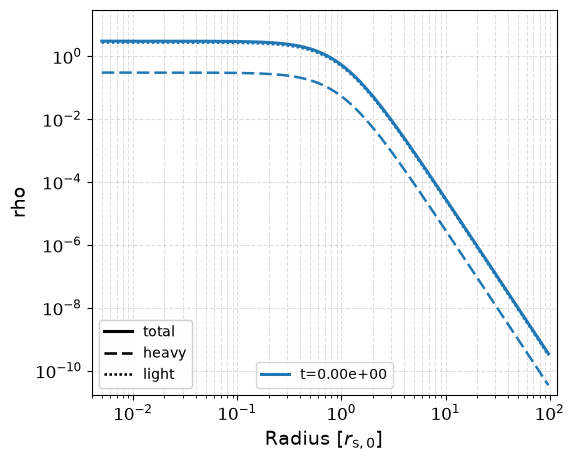

In [12]:
gtf.plot_snapshots(state, grid=True)

These, as well as the time evolution plots, can optionally be saved using the `filepath` keyword.  `show=True` displays the plot as well as saving it.

The available profiles are `rho`, `m`, `v2`, and `eta`.  Density, mass, and velocity dispersion plots include the total system and each species.  `eta` is the fitted equipartition index, $σ \propto m_\mathrm{part}^{-η}$; full equipartition corresponds to $η=1/2$.

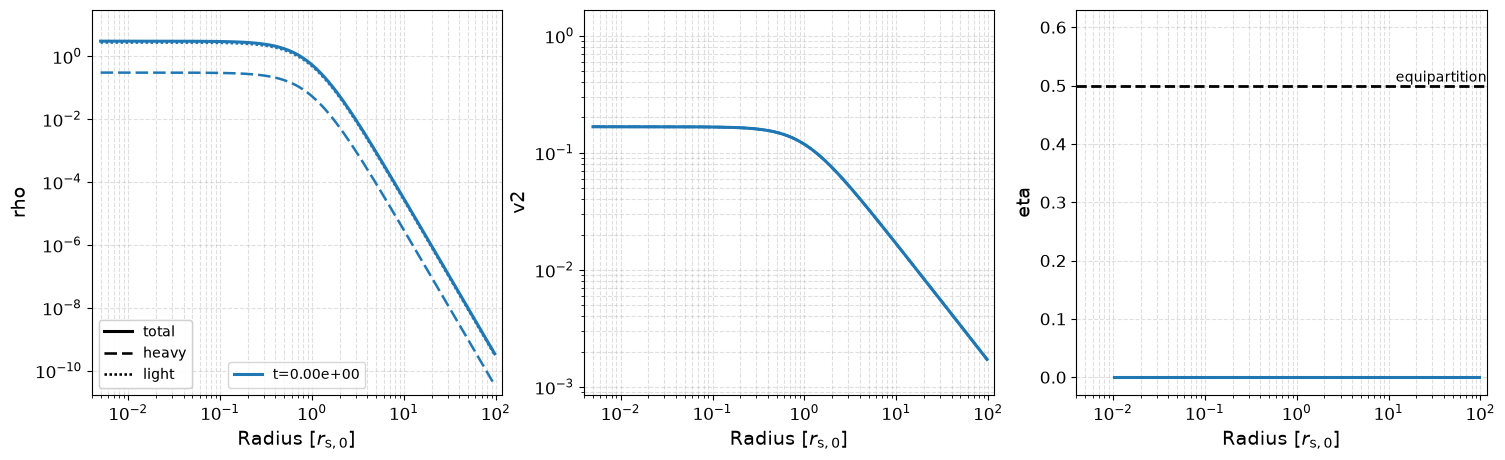

In [13]:
gtf.plot_snapshots(
    state, grid=True, profiles=['rho', 'v2', 'eta'],
    filepath=str(model_dir / 'initial.png'), show=True
)

# Run simulation

In each integration step:
- Energy transport updates `v2` through conduction within species and heat exchange between species, with optional binary heating.
- The time step is reduced if necessary to satisfy `config.prec.eps_du`.
- The revirialization step reestablishes hydrostatic equilibrium by adjusting the radial shell edges, keeping each species' shell masses fixed and updating density and pressure.
- `v2`, shell midpoints, time, and diagnostics are updated.

Without arguments, `run()` continues until a configured stopping condition is reached: `config.sim.t_halt` (default 1000), `config.sim.rho0_halt` (default $10^8$, checked after step 1000), or a NaN central density.  Numerical failures can also stop the run with an exception.

Additional stopping conditions are `steps`, `stoptime`, and `rho0`.  `stoptime` is an **additional duration** in simulation time units; `rho0` is a total central density threshold.  The configured limits still apply.

Here we follow mass segregation and core contraction using central density milestones rather than a fixed step count.  First evolve to `rho0=100`, then continue to `rho0=1e4`.  The initial central density is about 3 in these units, so the full run follows more than three orders of magnitude of density growth.  The adaptive time step becomes smaller as the core contracts.

The final density is a finite stopping point before the formal collapse singularity; extending further should be accompanied by checks of spatial resolution and numerical tolerances.

In [14]:
state.run(rho0=100.0)

Initial profiles written to disk.
Time evolution file initialized.
Log file initialized:
      step          time          <dt>          rho0  r50_spread  <du lim>  <n_iter_du>
         0  0.000000e+00           N/A  2.999550e+00  0.0000e+00       N/A          N/A
     25000  3.714290e+00  1.485716e-04  1.016839e+01  7.7394e-01  9.90e-01  1.20000e-04
Simulation halted: user stopping condition reached
     42537  7.902023e+00  2.387942e-04  1.000095e+02  1.3535e+00  9.90e-01  0.00000e+00
Total time for run(): 3.07s


Repeated `run()` calls continue from the current state.  The following continues the same simulation to a total central density of $10^4$.  `rho0` is an absolute threshold, whereas `stoptime` specifies an additional duration; `steps` remains useful for short numerical checks.

Profiles and time evolution are saved according to `config.io.drho_prof`, `drho_tevol`, and `dr50_tevol`, and at the start and end of each `run()` call.  The density-based cadence resolves the increasingly rapid contraction without choosing a fixed interval in time.

In [15]:
state.run(rho0=1.0e4)

state.t, state.step_count, state.rho0

      step          time          <dt>          rho0  r50_spread  <du lim>  <n_iter_du>
     42537  7.902023e+00           N/A  1.000095e+02  1.3535e+00       N/A          N/A
     50000  8.625882e+00  9.699306e-05  3.151460e+02  1.4622e+00  9.90e-01  0.00000e+00
Simulation halted: user stopping condition reached
     70731  9.101485e+00  1.489050e-04  1.000046e+04  1.5046e+00  6.43e+00  0.00000e+00
Total time for run(): 2.17s


(9.101484872743546, 70731, 10000.458532578104)

Check finite, positive fluid variables, ordered shells, and conserved shell masses.  These are useful diagnostics; they do not establish convergence.  The stopping threshold is tested after an accepted step, so the final density can slightly exceed the target.

In [16]:
checks = {
    'finite density and dispersion': bool(np.isfinite(state.rho).all() and np.isfinite(state.v2).all()),
    'positive density and dispersion': bool((state.rho > 0).all() and (state.v2 > 0).all()),
    'ordered shell edges': bool((np.diff(state.r, axis=1) > 0).all()),
    'conserved shell masses': bool(np.allclose(state.m, initial_m, rtol=1e-12, atol=0)),
    'density target reached': bool(state.rho0 >= 1e4),
}
print(checks)
assert all(checks.values())
print('Elapsed physical time [Gyr]:', state.t * state.char.t0)

{'finite density and dispersion': True, 'positive density and dispersion': True, 'ordered shell edges': True, 'conserved shell masses': True, 'density target reached': True}
Elapsed physical time [Gyr]: 6.016682022365291


The older demo reloaded simulations with `State.from_dir()`.  That method currently raises `RuntimeError("this module is still in development")`, so we keep using the live State here.  Saved outputs can still be read and plotted without reconstructing a State, as shown below.

# Inspect/present results

`rho0` plots the innermost density, while `rho_c` plots the mean density within the core radius.  Both include total and per-species curves.  Use a linear y-axis for `eta_c`, which can start at zero.

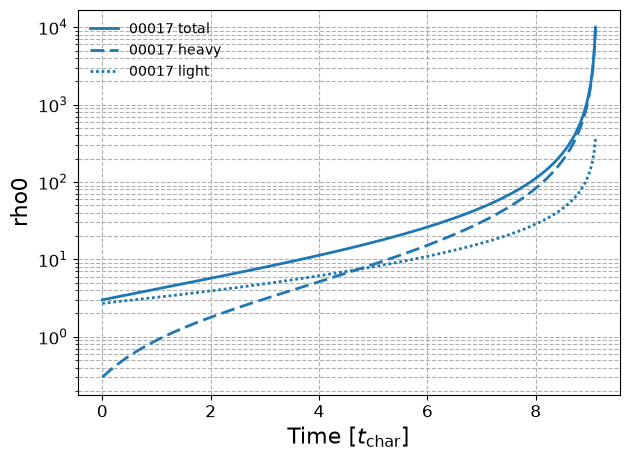

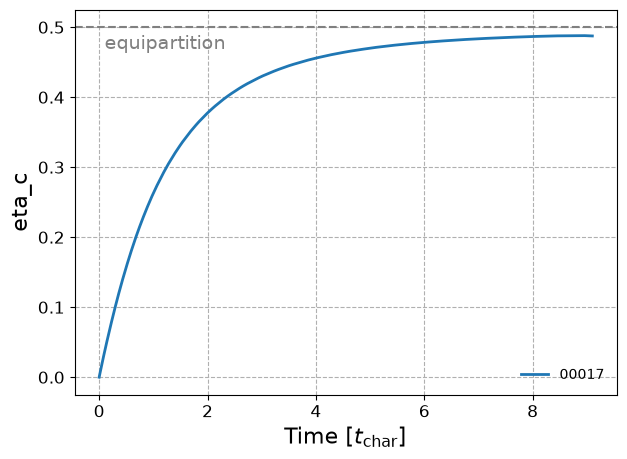

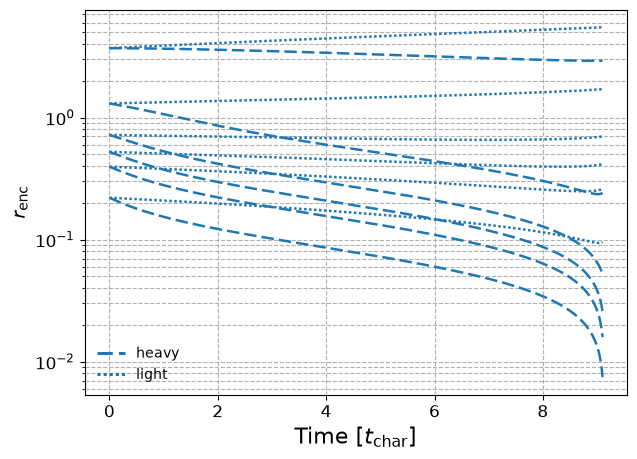

In [17]:
state.plot_time_evolution(grid=True, quantity='rho0')
state.plot_time_evolution(grid=True, quantity='eta_c', logy=False)
state.plot_time_evolution(grid=True, quantity='r_enc')

`r_enc` shows the radii enclosing 1, 5, 10, 20, 50, and 90 percent of each species' mass.  Other supported quantities are `rho_c`, `v2_c`, `r_c`, `m_c`, and `v20_tot`.

`plot_time_evolution()` also exists as a standalone function and can compare multiple simulations.  Here we create a second model with a smaller particle mass contrast, keeping the initial profile shapes and mass fractions the same.

In [18]:
config_compare = gtf.Config(
    mtot=config.mtot,
    io={'base_dir': str(base_dir)},
    grid=deepcopy(config.grid),
    sim=deepcopy(config.sim),
    prec=deepcopy(config.prec),
)
for name, species in config.spec.items():
    config_compare.add_species(
        name, m_part=1.5 if name == 'heavy' else species.m_part,
        frac=species.frac, init=deepcopy(species.init)
    )

state_compare = gtf.State.from_config(config_compare)
# Compare over the same physical duration (the models have different t0).
duration = state.t * state.char.t0 / state_compare.char.t0
state_compare.run(stoptime=duration)

Setting species hierarchy...
Computing characteristic parameters for simulation...
Setting up radial grids for all species...
Setting parameters for background potential...
	No background potential.
Initializing profiles...
Ensuring initial hydrostatic equilibrium...
	Initial pressure correction applied. HE residual improved 6.675e-02 -> 3.835e-12.
	Hydrostatic equilibrium achieved in 1 iterations. Max |dr/r| = 8.67e-17.  HE res 3.0202433023998217e-10
State initialized.
'model_no' set to 18
Created directory: /Users/yaronetokayer/Documents/codex_workspace/gtf/pygtf2/examples/demo_output/Model00018
Characteristic parameters written to char_params.txt
Model information written to model_metadata.txt
Initial profiles written to disk.
Initial profiles written to disk.
Time evolution file initialized.
Log file initialized:
      step          time          <dt>          rho0  r50_spread  <du lim>  <n_iter_du>
         0  0.000000e+00           N/A  2.999550e+00  0.0000e+00       N/A         

Pass a list of State objects, Config objects, or integer model numbers.  Integer model numbers require `base_dir`.  This also works in a later session using outputs written by the current code, even though `State.from_dir()` is unavailable.

The horizontal axis is each model's dimensionless time, $t/t_0$; the characteristic time differs when the particle masses change.  The stopping duration is checked after each step, so the second run can slightly exceed the requested duration.

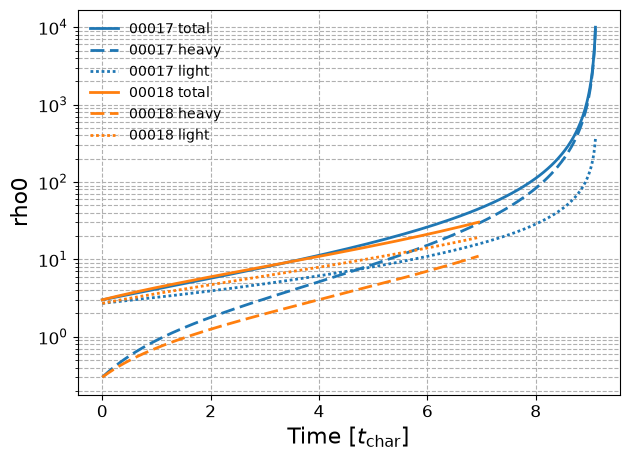

In [19]:
model_numbers = [config.io.model_no, config_compare.io.model_no]

gtf.plot_time_evolution(
    models=model_numbers,
    quantity='rho0',
    grid=True,
    base_dir=str(base_dir),
    filepath=str(model_dir / 'compare.png'),
    show=True
)

When plotting snapshots, the index `-1` corresponds to the latest saved snapshot.

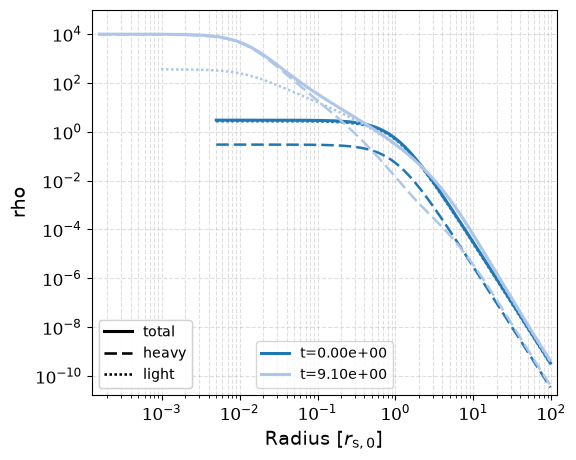

In [20]:
state.plot_snapshots(grid=True, snapshots=[0, -1])

Read the available indices from `snapshot_conversion.txt` instead of assuming that a particular snapshot exists.  Here we select up to six snapshots spread across the saved evolution.

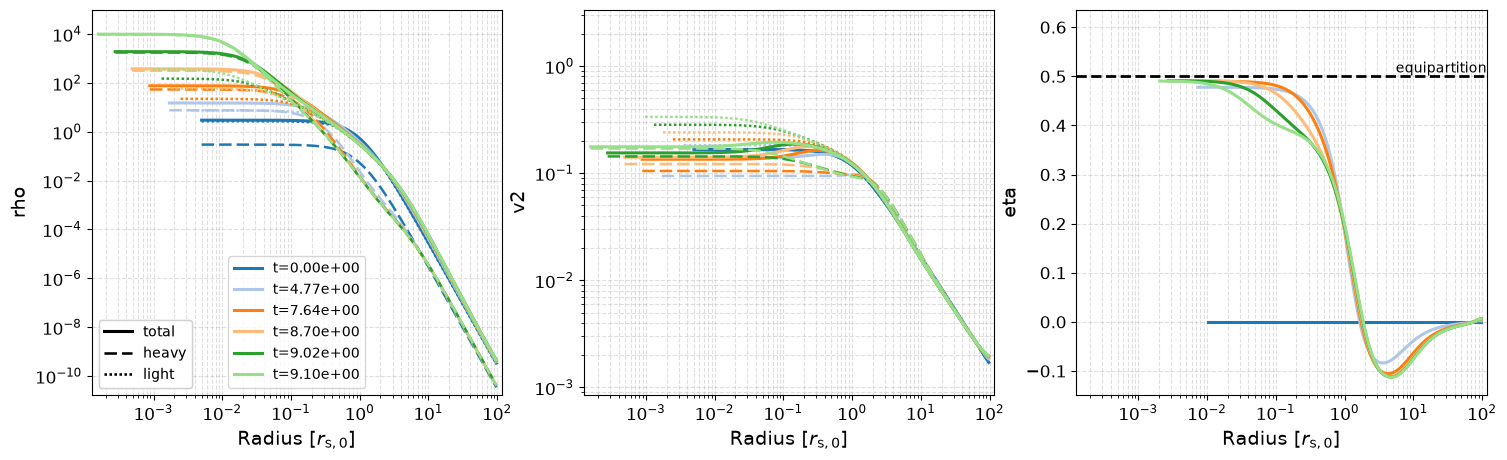

In [21]:
from pygtf2.io.read import extract_snapshot_indices

snapshot_times = extract_snapshot_indices(str(model_dir))
indices = snapshot_times['index']
positions = np.linspace(0, len(indices) - 1, min(6, len(indices)), dtype=int)
snapshots = [int(indices[i]) for i in positions]

state.plot_snapshots(
    grid=True, snapshots=snapshots, profiles=['rho', 'v2', 'eta']
)

Profiles can also be plotted against total enclosed mass.  Give one `xaxis` entry for each panel.

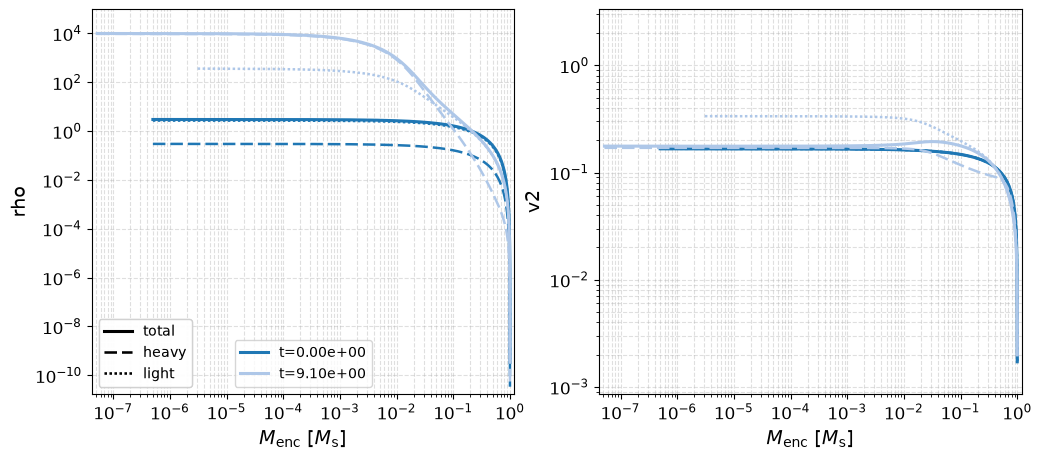

In [22]:
state.plot_snapshots(
    grid=True, snapshots=[0, -1], profiles=['rho', 'v2'],
    xaxis=['m', 'm']
)

## Read outputs directly

The readers in `pygtf2.io.read` expose the saved tables as dictionaries of NumPy arrays.  Per-species entries are nested under `species`, keyed by the original label.  Profile radii are saved as base-10 logarithms; mass is tabulated at outer edges, without the central zero edge.

`rho0_tot` is the innermost total density; `rho_c_tot` is the core-averaged density.  Snapshot `eta` is a radial profile, while time-series `eta_c` is the core value.  `snapshot_conversion.txt` connects snapshot indices, time, time in Gyr, and integration steps.

In [23]:
from pygtf2.io.read import extract_snapshot_data, extract_time_evolution_data, import_metadata

history = extract_time_evolution_data(str(model_dir / 'time_evolution.txt'))
last_index = int(indices[-1])
saved = extract_snapshot_data(str(model_dir / f'profile_{last_index}.dat'))

print('Global history columns:', [key for key in history if key != 'species'])
print('Species history columns:', list(history['species']['heavy']))
print('Snapshot columns:', [key for key in saved if key != 'species'])
print('Saved species:', list(saved['species']))
print('Latest snapshot:', last_index, 'at t =', saved['time'])
assert np.isclose(saved['time'], state.t, rtol=1e-5)

Global history columns: ['step', 'time', 'rho0_tot', 'v20_tot', 'r_c', 'v2_c', 'm_c', 'rho_c_tot', 'eta_c', 'rho0[heavy]', 'rho_c[heavy]', 'r01[heavy]', 'r05[heavy]', 'r10[heavy]', 'r20[heavy]', 'r50[heavy]', 'r90[heavy]', 'r50evo[heavy]', 'm_c[heavy]', 'rho0[light]', 'rho_c[light]', 'r01[light]', 'r05[light]', 'r10[light]', 'r20[light]', 'r50[light]', 'r90[light]', 'r50evo[light]', 'm_c[light]', 'model_id']
Species history columns: ['rho0', 'rho_c', 'r01', 'r05', 'r10', 'r20', 'r50', 'r90', 'r50evo', 'm_c']
Snapshot columns: ['i', 'log_r', 'log_rmid', 'm_tot', 'rho_tot', 'v2_tot', 'eta', 'time']
Saved species: ['heavy', 'light']
Latest snapshot: 87 at t = 9.101485


For example, plot the enclosed mass using the saved species radii, or plot a Config directly with the built-in plotting functions.  Both approaches work without `State.from_dir()`.

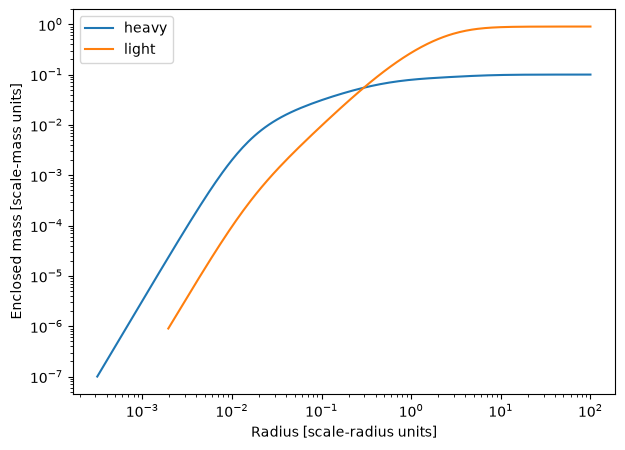

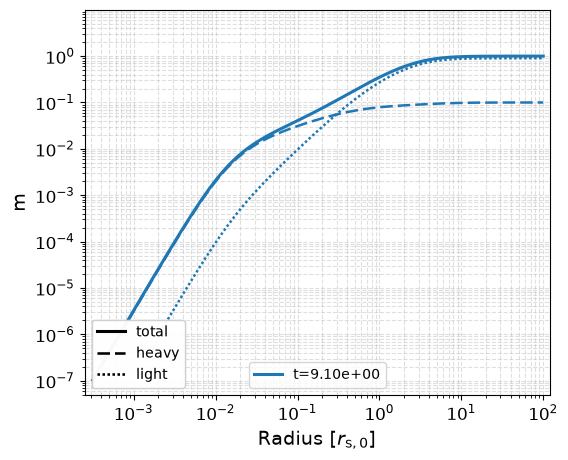

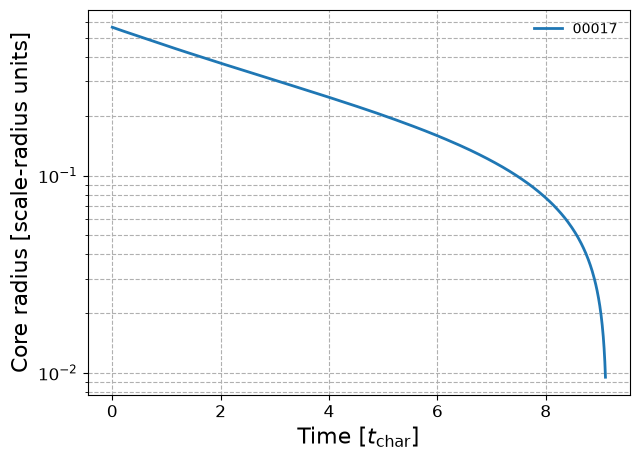

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
for name, species in saved['species'].items():
    ax.loglog(10**species['lgr'], species['m'], label=name)
ax.set(xlabel='Radius [scale-radius units]', ylabel='Enclosed mass [scale-mass units]')
ax.legend()
plt.show()

gtf.plot_snapshots(config, snapshots=-1, profiles='m', grid=True)
gtf.plot_time_evolution(config, quantity='r_c', grid=True, ylabel='Core radius [scale-radius units]')

## Compare in physical units

The built-in time-evolution plot uses each model's own dimensionless time.  For a comparison at the same physical age, convert the time arrays explicitly.  `state.char.t0` is in Gyr and `state.char.v0` is the velocity scale in km/s.  Multiply dimensionless density and mass by `rho_s` and `m_s`, respectively; radius uses the length unit of `r_s`.

The current source has inconsistent kpc/Mpc labels in some characteristic-scale docstrings, so do not infer a length unit from those labels alone.  The plots below use the implemented time and velocity conversions.

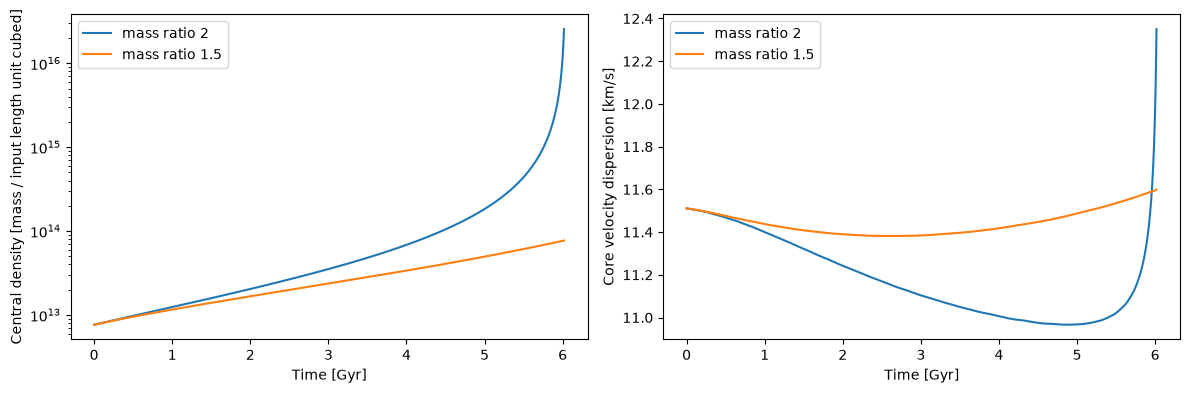

In [25]:
compare_dir = Path(config_compare.io.base_dir) / config_compare.io.model_dir
history_compare = extract_time_evolution_data(str(compare_dir / 'time_evolution.txt'))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for current, data, label in [
    (state, history, 'mass ratio 2'),
    (state_compare, history_compare, 'mass ratio 1.5'),
]:
    physical_time = data['time'] * current.char.t0
    axs[0].plot(physical_time, data['rho0_tot'] * current.char.rho_s, label=label)
    axs[1].plot(physical_time, np.sqrt(data['v2_c']) * current.char.v0, label=label)
axs[0].set(yscale='log', ylabel='Central density [mass / input length unit cubed]')
axs[1].set(ylabel='Core velocity dispersion [km/s]')
for ax in axs:
    ax.set_xlabel('Time [Gyr]')
    ax.legend()
plt.tight_layout()
plt.show()

## Recover a configuration and start a new experiment

`import_metadata()` and `Config.from_dict()` reconstruct the input configuration, not the evolved state.  Reassign `io` before starting another model: the saved configuration retains its old output directory and model number.

This helper makes an independent copy with automatic model numbering and will be used for the experiments below.

In [26]:
from pygtf2.parameters.io_params import IOParams

metadata = import_metadata(str(model_dir))
recovered_config = gtf.Config.from_dict(metadata)
print('Recovered mass and species:', recovered_config.mtot, list(recovered_config.spec))

def new_experiment(template):
    result = deepcopy(template)
    result.io = IOParams(base_dir=str(base_dir), chatter=False, nupdate=100000)
    return result

recovered_config = new_experiment(recovered_config)
assert recovered_config.s == config.s

Recovered mass and species: 500000.0 ['heavy', 'light']


## Binary heating and post-collapse oscillations

The earlier density ceiling of $10^4$ stops before binary heating reverses collapse.  Here we instead follow a 30,000-particle cluster through several contraction and expansion episodes.  We retain the two particle masses, mass fractions, and initial profile shapes, and set the total mass consistently using $N=M_\mathrm{tot}\sum_k f_k/m_k$.  This is a separate cluster, not a controlled heating-only comparison with the preceding 500,000-solar-mass model.

Set `sim.binaries=True` and supply `sim.n_particle` explicitly.  Raise `rho0_halt` above the bounce densities so the default density limit does not truncate the oscillations.  We evolve to $t=9.2$ in this model's simulation units, an endpoint selected from a pilot run to include repeated post-collapse cycles.  Changing the particle number, mass spectrum, profile, or numerical settings can change the required endpoint.

This demonstrates the fluid model's oscillatory evolution; it does not establish convergence of post-collapse amplitudes or periods.  The earlier resolution example tested only the unheated evolution to $\rho_0=10^4$.

This is the longest example in the notebook: the saved run takes about 1.84 million adaptive steps.  Allow a few minutes for this cell, depending on the machine.

Total time for run(): 3m28.74s
Particle count / total mass: 30000 31578.94736842105
Final (time, steps, central density): 9.20000187629991 1840297 46114.425373955724


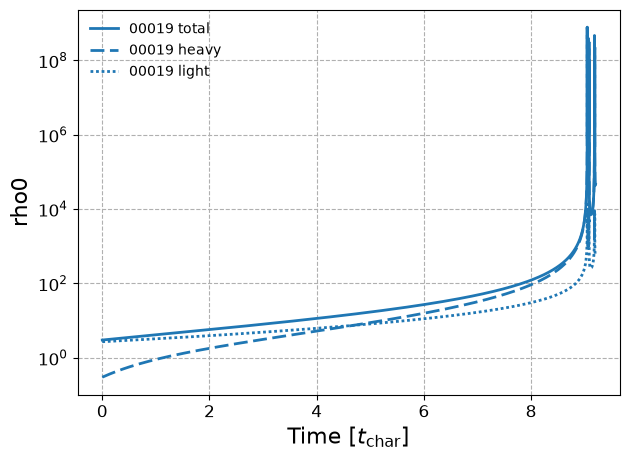

In [27]:
config_binary = new_experiment(config)
config_binary.sim.binaries = True
config_binary.sim.n_particle = 30000
config_binary.mtot = config_binary.sim.n_particle / sum(
    sp.frac / sp.m_part for sp in config_binary.spec.values()
)
config_binary.sim.rho0_halt = 1e12
config_binary.sim.t_halt = 10.0
config_binary.io.drho_tevol = 0.03
config_binary.io.nupdate = 100000

state_binary = gtf.State.from_config(config_binary)
state_binary.run(stoptime=9.2)
print('Particle count / total mass:', config_binary.sim.n_particle, config_binary.mtot)
print('Final (time, steps, central density):', state_binary.t, state_binary.step_count, state_binary.rho0)
gtf.plot_time_evolution(state_binary, quantity='rho0', grid=True)

The full-run time axis compresses the oscillations near the end.  Inspect the post-collapse interval separately.  We identify density peaks with at least one dex of prominence (a factor of ten in density), so shallow shoulders are not counted as full cycles.  The assertion below checks that the saved run actually includes at least three such peaks and two troughs.

The core radius varies oppositely to core density, while the equipartition index traces the changing core state.  These plots use saved diagnostics; the reported cycle count is an operational check for this example, not a stability classification.

Large density peaks / troughs: 8 7
Peak times: [9.046572 9.04933  9.062316 9.063466 9.078831 9.080876 9.181692 9.186551]


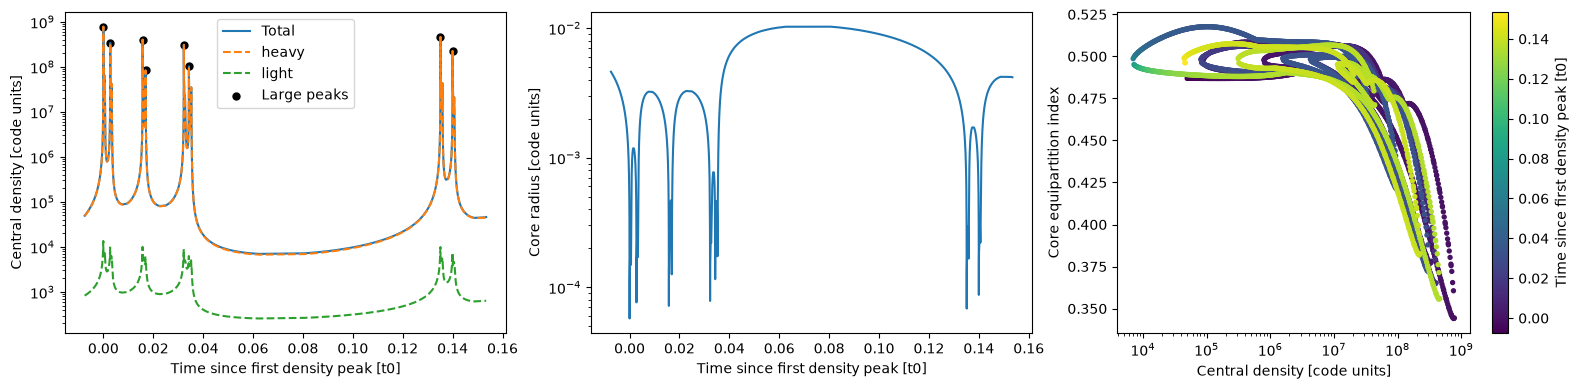

In [28]:
from scipy.signal import find_peaks

binary_dir = Path(config_binary.io.base_dir) / config_binary.io.model_dir
binary_history = extract_time_evolution_data(str(binary_dir / 'time_evolution.txt'))
log_density = np.log10(binary_history['rho0_tot'])
peaks, _ = find_peaks(log_density, prominence=1.0)
troughs, _ = find_peaks(-log_density, prominence=1.0)
assert state_binary.t >= 9.2, 'Run stopped before the requested duration.'
assert len(peaks) >= 3 and len(troughs) >= 2, 'Extend the run to resolve more oscillations.'
print('Large density peaks / troughs:', len(peaks), len(troughs))
print('Peak times:', binary_history['time'][peaks])

first_peak_time = binary_history['time'][peaks[0]]
zoom_start = first_peak_time - 0.05 * (state_binary.t - first_peak_time)
post = binary_history['time'] >= zoom_start
elapsed = binary_history['time'][post] - first_peak_time
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].semilogy(elapsed, binary_history['rho0_tot'][post], label='Total')
for name, species in binary_history['species'].items():
    axs[0].semilogy(elapsed, species['rho0'][post], '--', label=name)
axs[0].scatter(binary_history['time'][peaks] - first_peak_time,
               binary_history['rho0_tot'][peaks], color='black', s=25, label='Large peaks')
axs[0].set(xlabel='Time since first density peak [t0]', ylabel='Central density [code units]')
axs[0].legend()
axs[1].semilogy(elapsed, binary_history['r_c'][post])
axs[1].set(xlabel='Time since first density peak [t0]', ylabel='Core radius [code units]')
points = axs[2].scatter(binary_history['rho0_tot'][post], binary_history['eta_c'][post],
                        c=elapsed, s=8, cmap='viridis')
axs[2].set(xscale='log', xlabel='Central density [code units]', ylabel='Core equipartition index')
fig.colorbar(points, ax=axs[2], label='Time since first density peak [t0]')
plt.tight_layout()
plt.show()

## A static background potential

`sim.bkg` describes an external Hernquist mass distribution.  Supply all four keys: `prof`, `mass`, `length`, and `other`.  `mass` uses solar masses and `length` uses the same input length unit as `r_s`; `other=None` is appropriate for the static profile.  The background is not an evolving species.

The property returns a copy, so assign the complete dictionary rather than changing `config.sim.bkg['mass']` in place.  A background also changes the characteristic relaxation time.  This example runs for one background-model time unit, with a central density ceiling.

Total time for run(): 1.01s
Final (time, steps, central density): 1.0000806970122993 14105 5.042354702594822


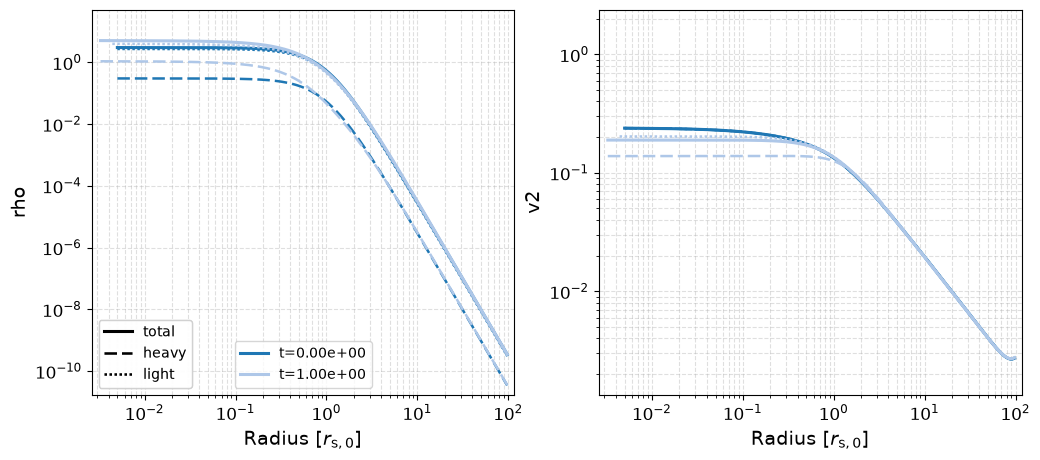

In [29]:
config_background = new_experiment(config)
config_background.sim.bkg = {
    'prof': 'hernq_static',
    'mass': 0.2 * config_background.mtot,
    'length': config_background.spec['heavy'].init.r_s,
    'other': None,
}
state_background = gtf.State.from_config(config_background)
state_background.run(stoptime=1.0, rho0=1e4)
print('Final (time, steps, central density):', state_background.t, state_background.step_count, state_background.rho0)
state_background.plot_snapshots(snapshots=[0, -1], profiles=['rho', 'v2'], grid=True)

## Check resolution and time-step tolerance

A successful run alone is not a convergence test.  Here we increase the number of radial shells from 180 to 240 and halve `eps_du`, then compare the time required to reach the same central density.  Both changes are combined for a compact demonstration; a systematic study should vary them separately and also check the radial domain and profile quadrature.

The fractional difference printed below is a diagnostic, not an imposed accuracy guarantee.

Total time for run(): 12.62s
Baseline / refined steps: 70731 141552
Baseline / refined times: 9.101484872743546 9.101427885331752
Fractional time difference: -6.261331265253465e-06


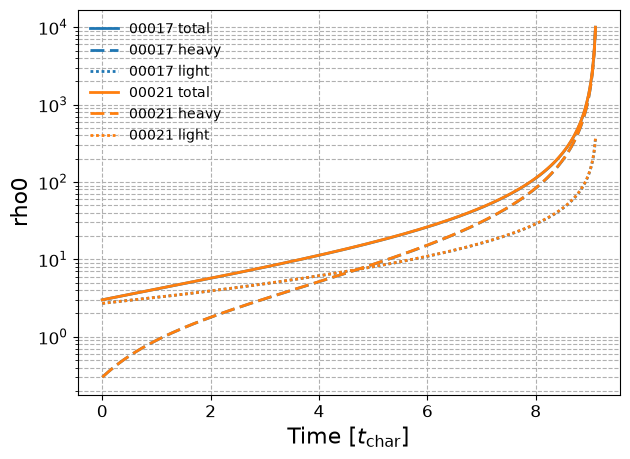

In [30]:
config_refined = new_experiment(config)
config_refined.grid.ngrid = 240
config_refined.prec.eps_du = config.prec.eps_du / 2
state_refined = gtf.State.from_config(config_refined)
state_refined.run(rho0=1e4)
assert state_refined.rho0 >= 1e4

fractional_time_difference = (state_refined.t - state.t) / state.t
print('Baseline / refined steps:', state.step_count, state_refined.step_count)
print('Baseline / refined times:', state.t, state_refined.t)
print('Fractional time difference:', fractional_time_difference)
gtf.plot_time_evolution([state, state_refined], quantity='rho0', grid=True)

## Reset an in-memory state

`reset()` recomputes the initial arrays and resets time, step count, and snapshot counter.  It does not immediately rewrite the saved files.  Running that reset State again can replace outputs in the same model directory, and plotting methods still read the saved files until new output is written.

To illustrate the reset without disturbing the main simulation, reset an independent in-memory copy.  For a new on-disk run, prefer a new Config with fresh `io`, as above.

In [31]:
reset_example = deepcopy(state)
reset_example.config.io.chatter = False
reset_example.reset()
print('Reset (time, steps, snapshot counter):', reset_example.t, reset_example.step_count, reset_example.snapshot_index)
print('Original (time, steps):', state.t, state.step_count)
assert reset_example.t == 0 and reset_example.step_count == 0
assert np.allclose(reset_example.m, initial_m)
del reset_example

Reset (time, steps, snapshot counter): 0.0 0 0
Original (time, steps): 9.101484872743546 70731


## Current limitations

- `State.from_dir()` is disabled; use the readers for analysis and Config reconstruction for a fresh run.  It is not currently possible to resume a saved State through that method.
- `sim.conduct_imex=False` selects a deprecated branch that raises an error.
- `sim.evap` exists, but evaporation calls are commented out in the current integrator.
- `hernq_decay` is accepted by the configuration, but the force calculation currently implements only `hernq_static`; do not use it as a time-dependent background.
- For one species, or equal particle masses, an equipartition fit is not informative; the writer uses a placeholder zero.
- Some docstrings still describe older quantities.  The built-in snapshot profiles are `rho`, `m`, `v2`, and `eta`; the examples above use the current implementations.

# Animate the evolution

`make_movie()` writes an MP4 with fixed axis limits throughout the evolution, optional time evolution insets, and marked radii.  It requires `ffmpeg` to be installed and callable from the kernel's environment.  Set `make_animation=True` to generate it.  The default output is `movie.mp4` in this model's directory.

Here the density panel includes a central density inset and the velocity dispersion panel includes the core equipartition index.  Inset names are columns from `time_evolution.txt`, e.g., `rho0_tot`; provide one inset entry per panel, using `None` for no inset.

In [32]:
make_animation = False

if make_animation:
    gtf.make_movie(
        state, grid=True, profiles=['rho', 'v2', 'eta'],
        insets=['rho0_tot', 'eta_c', None],
        add_radii=['r_c'],
    )

`gtf.make_movie()` accepts a State, Config, or integer model number (with `base_dir`), and is also available as `state.make_movie()`.  Rendering is parallel by default; use `parallel=False` to render serially.

Use `insets=False` to disable all insets, or a list such as `[None, None, None]` to choose them panel by panel.  With no insets or marked radii, `time_evolution.txt` is not required.  Axis limits stay fixed throughout the movie.

See the function's help for the current plotting options.

For a plain movie, the State method is convenient.  This second example uses serial rendering, no insets, a mass-coordinate x-axis, an explicit frame rate, and a separate filename.  The filename prevents overwriting the first movie.  `make_animation=False` leaves both MP4 examples disabled during the normal notebook run.

In [33]:
if make_animation:
    state.make_movie(
        profiles=['rho', 'v2'], insets=False, xaxis='m',
        parallel=False, fps=15,
        filepath=str(model_dir / 'movie_mass_coordinate.mp4'),
    )

After generating a movie, display it inline in Jupyter.  Rendering is based on saved snapshots, so animation frames follow the snapshot cadence rather than uniformly spaced physical times.

In [34]:
if make_animation:
    from IPython.display import Video, display
    display(Video(str(model_dir / 'movie.mp4'), embed=True))

In [35]:
help(gtf.make_movie)
help(gtf.plot_snapshots)

Help on function make_movie in module pygtf2.plot.snapshot:

make_movie(model, parallel=True, *, profiles=None, insets=None, xaxis=None, add_radii=None, filepath=None, base_dir=None, grid=False, fps=20)
    Animate saved profiles with fixed axes across the entire evolution.

    Parameters
    ----------
    model : State, Config, or int
        Simulation to animate. Integer model numbers require base_dir.
    parallel : bool, optional
        Render frames in separate processes (default True). Set False for
        serial rendering, including environments without multiprocessing.
    profiles : str or list of str, optional
        Up to three of 'rho', 'm', 'v2', 'eta'. Defaults to ['rho', 'v2'].
    insets : None, False, str, or list of str or None, optional
        None uses 'rho_c_tot' in the first panel. False disables all insets.
        Otherwise provide one time_evolution.txt column per panel, with None
        for panels without insets. A string is accepted for a single panel